## 1. Data Loading:

In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]
X.shape

(70000, 784)

### 1.1 Train-Test split

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.


## 2. Autoencoder Architecture:

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# encoder

encoder = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu')
])  

# decoder
decoder = keras.Sequential([
    layers.Input(shape=(32,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(784, activation='sigmoid')
])

# autoencoder
inputs = keras.Input(shape=(784,))
encoded = encoder(inputs)
decoded = decoder(encoded)

autoencoder = keras.Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32)             │       110,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 784)            │       111,568 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Training:

In [4]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=20,
    batch_size=64,
    shuffle=True,
    validation_data=(X_test, X_test)
)

Epoch 1/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0401 - val_loss: 0.0242
Epoch 2/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0210 - val_loss: 0.0188
Epoch 3/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0173 - val_loss: 0.0160
Epoch 4/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0151 - val_loss: 0.0142
Epoch 5/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0137 - val_loss: 0.0132
Epoch 6/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0127 - val_loss: 0.0126
Epoch 7/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0120 - val_loss: 0.0119
Epoch 8/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0115 - val_loss: 0.0114
Epoch 9/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0111 - val_loss: 0.0109
Epoch 10/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0107 - val_loss: 0.0106
Epoch 11/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0104 - val_loss: 0.0103
Epoch 12/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

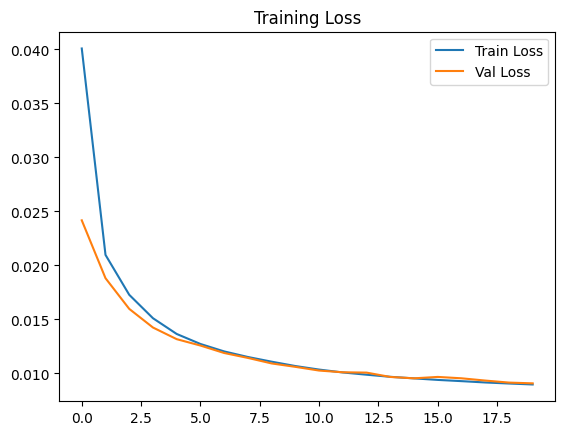

In [5]:
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Training Loss")
plt.show()

## 4. Reconstruction Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


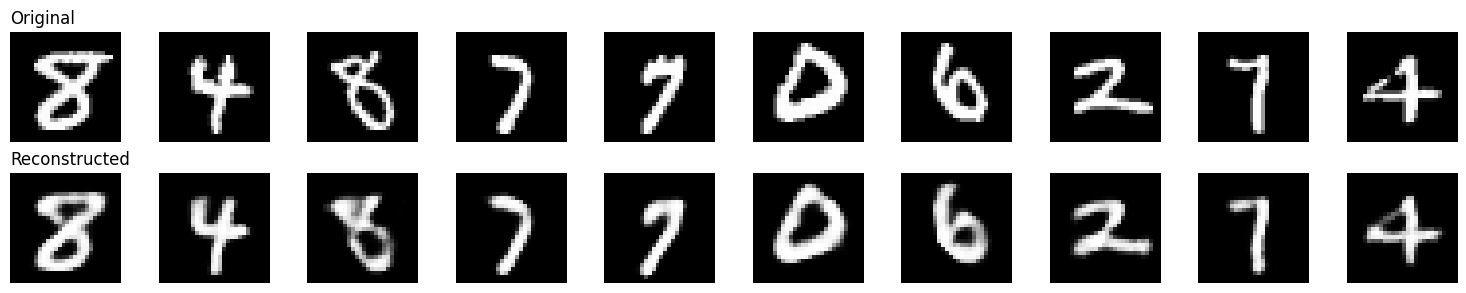

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [ ]:
reconstructed = autoencoder.predict(X_test[:10])

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
   
    axes[0, i].imshow(X_test[i].reshape(28, 28), cmap="gray")
    axes[0, i].axis("off")
   

    axes[1, i].imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_title("Original",      loc="left")
axes[1, 0].set_title("Reconstructed", loc="left")
plt.tight_layout()
plt.show()

## 5. Dimensionality Reduction (t-SNE)

In [7]:
from sklearn.manifold import TSNE

encoded_test = encoder.predict(X_test)  

encoded_2d = TSNE(n_components=2, random_state=42).fit_transform(encoded_test[:2000])

438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 260us/step


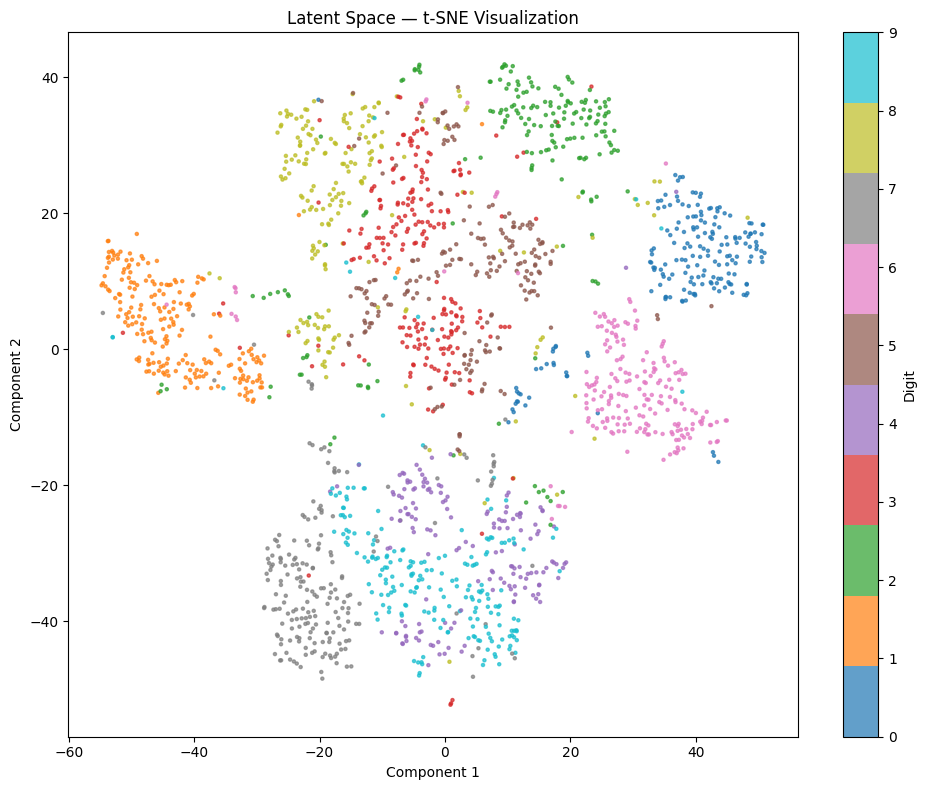

In [8]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    encoded_2d[:, 0],
    encoded_2d[:, 1],
    c=y_test[:2000].astype(int),  
    cmap="tab10",
    s=5,
    alpha=0.7
)
plt.colorbar(scatter, label="Digit")
plt.title("Latent Space — t-SNE Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.tight_layout()
plt.show()

## 6. Image Retrieval (Cosine Similarity)

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

encoded_train  = encoder.predict(X_train)

index = 10
sample = X_test[index].reshape(1, -1)
encoded_sample = encoder.predict(sample)

similarities = cosine_similarity(encoded_sample, encoded_train)[0]


top_idx = np.argsort(similarities)[::-1][:10]



1750/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 255us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


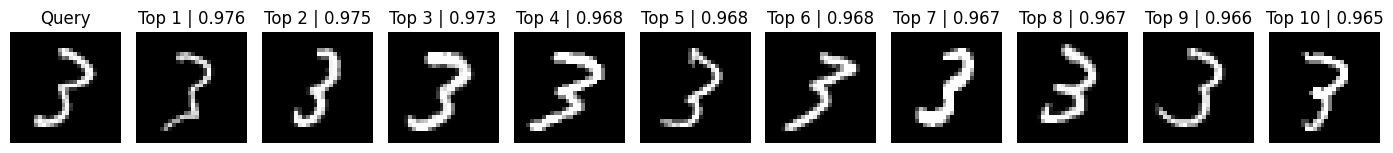

In [10]:
fig, axes = plt.subplots(1, 11, figsize=(14, 3))

axes[0].imshow(sample.reshape(28, 28), cmap="gray")
axes[0].set_title("Query")
axes[0].axis("off")

for i, idx in enumerate(top_idx):
    axes[i+1].imshow(X_train[idx].reshape(28, 28), cmap="gray")
    axes[i+1].set_title(f"Top {i+1} | {similarities[idx]:.3f}")
    axes[i+1].axis("off")

plt.tight_layout()
plt.show()